<a href="https://colab.research.google.com/github/Striver29/CrossEnrich/blob/main/CrossEnrich_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phase 1: Hardcoded data collection**

In [1]:
!pip install gprofiler-official matplotlib seaborn --quiet
print("done")

done


In [2]:
from gprofiler import GProfiler
import pandas as pd

In [3]:
gene_list = ["TP53", "MDM2", "CDKN1A", "BAX", "BBC3", "PMAIP1", "GADD45A", "GADD45B",
"SESN1", "SESN2", "RRM2B", "DRAM1", "FAS", "TNFRSF10B", "APAF1",
"CASP3", "CASP9", "CYCS", "PTEN", "ATM", "ATR", "BRCA1", "BRCA2"]

print(len(gene_list))
print(gene_list)

23
['TP53', 'MDM2', 'CDKN1A', 'BAX', 'BBC3', 'PMAIP1', 'GADD45A', 'GADD45B', 'SESN1', 'SESN2', 'RRM2B', 'DRAM1', 'FAS', 'TNFRSF10B', 'APAF1', 'CASP3', 'CASP9', 'CYCS', 'PTEN', 'ATM', 'ATR', 'BRCA1', 'BRCA2']


In [4]:
gp = GProfiler()
results = gp.profile(gene_list, organism="hsapiens", no_evidences=False) #no_evidences=False is set to show intersections
results = pd.DataFrame(results)
print(results.shape)

(608, 16)


In [5]:
results.head()

,description,effective_domain_size,intersection_size,intersections,name,native,p_value,parents,precision,query,query_size,recall,significant,source,term_size,evidences
0,p53 signaling pathway,8484,20,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",p53 signaling pathway,KEGG:04115,5.941134e-39,[KEGG:00000],0.909091,query_1,22,0.270270,True,KEGG,74,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
1,DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",DNA damage response,WP:WP707,8.715110e-36,[WP:000000],0.826087,query_1,23,0.275362,True,WP,69,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
2,miRNA regulation of DNA damage response,8752,19,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, GADD45...",miRNA regulation of DNA damage response,WP:WP1530,2.994203e-35,[WP:000000],0.826087,query_1,23,0.260274,True,WP,73,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."
3,Platinum drug resistance,8484,13,"[TP53, MDM2, CDKN1A, BAX, BBC3, PMAIP1, FAS, A...",Platinum drug resistance,KEGG:01524,1.175199e-20,[KEGG:00000],0.590909,query_1,22,0.180556,True,KEGG,72,"[[KEGG], [KEGG], [KEGG], [KEGG], [KEGG], [KEGG..."
4,miRNA regulation of p53 pathway in prostate ca...,8752,11,"[TP53, MDM2, BAX, BBC3, PMAIP1, TNFRSF10B, APA...",miRNA regulation of p53 pathway in prostate ca...,WP:WP3982,2.706305e-20,[WP:000000],0.478261,query_1,23,0.354839,True,WP,31,"[[WP], [WP], [WP], [WP], [WP], [WP], [WP], [WP..."


In [6]:
print(results["source"].unique())

<StringArray>
[ 'KEGG',    'WP',  'REAC', 'GO:BP',    'HP', 'GO:CC', 'MIRNA', 'CORUM',
 'GO:MF',    'TF',   'HPA']
Length: 11, dtype: str


**Note: We treat GO as three separate databases:**

GO:BP (Biological Processes)

GO:CC (Cellular Component)

GO:MF (Molecular Function)

For interpretability, GO is kept split into GO:BP, GO:CC, and GO:MF. In this notebook we also keep WP, giving six sources in the exploratory comparison: GO:BP, GO:CC, GO:MF, KEGG, REAC, and WP.

#**Phase 2: Source filtering**




In [7]:
df_gobp = results[results["source"] == "GO:BP"]
df_gocc = results[results["source"] == "GO:CC"]
df_gomf = results[results["source"] == "GO:MF"]
df_kegg = results[results["source"] == "KEGG"]
df_reac = results[results["source"] == "REAC"]
df_wp = results[results["source"] == "WP"]

The code below keeps only terms marked significant by g:Profiler after multiple-testing correction.

In [8]:
df_gobp = df_gobp[df_gobp["significant"] == True]
df_gocc = df_gocc[df_gocc["significant"] == True]
df_gomf = df_gomf[df_gomf["significant"] == True]
df_kegg = df_kegg[df_kegg["significant"] == True]
df_reac = df_reac[df_reac["significant"] == True]
df_wp = df_wp[df_wp["significant"] == True]

In [9]:
print("GO:BP ",df_gobp.shape)
print("GO:CC ",df_gocc.shape)
print("GO:MF ", df_gomf.shape)
print("KEGG ", df_kegg.shape)
print("REAC ", df_reac.shape)
print("WP ", df_wp.shape)

GO:BP  (236, 16)
GO:CC  (12, 16)
GO:MF  (13, 16)
KEGG  (54, 16)
REAC  (76, 16)
WP  (68, 16)


#**Phase 3: Consistency and Metrics**




**Term Jaccard**



In [10]:
#mock example of two databases and direct name matching.

df_kegg_set = set(df_kegg["name"])
df_reac_set = set(df_reac["name"])

union = df_kegg_set.union(df_reac_set)
intersection = df_kegg_set.intersection(df_reac_set)

jaccard = len(intersection)/len(union)
print(jaccard)

0.007751937984496124


In [11]:
print(intersection)

#only one direct match

{'Apoptosis'}


In [12]:
#function for cross-database name direct matching.

def term_jaccard(db1, db2):
  db1_set = set(db1["name"])
  db2_set = set(db2["name"])

  union = db1_set.union(db2_set)
  intersection = db1_set.intersection(db2_set)

  if len(union) == 0:
    jaccard = 0
  else:
    jaccard = len(intersection)/len(union)

  return jaccard

In [13]:
databases = [
    ("GO:BP", df_gobp),
    ("GO:CC", df_gocc),
    ("GO:MF", df_gomf),
    ("KEGG", df_kegg),
    ("REAC", df_reac),
    ("WP", df_wp)
]

db_names = [name for name, df in databases]
matrix_df = pd.DataFrame(index=db_names, columns=db_names, dtype=float)

for i in range(len(databases)):
    name_i, df_i = databases[i]
    for j in range(i+1, len(databases)):
        name_j, df_j = databases[j]
        score = term_jaccard(df_i, df_j)
        matrix_df.at[name_i, name_j] = score
        matrix_df.at[name_j, name_i] = score

print(matrix_df)

        GO:BP  GO:CC  GO:MF      KEGG      REAC        WP
GO:BP     NaN    0.0    0.0  0.000000  0.000000  0.003300
GO:CC  0.0000    NaN    0.0  0.000000  0.000000  0.000000
GO:MF  0.0000    0.0    NaN  0.000000  0.000000  0.000000
KEGG   0.0000    0.0    0.0       NaN  0.007752  0.051724
REAC   0.0000    0.0    0.0  0.007752       NaN  0.006993
WP     0.0033    0.0    0.0  0.051724  0.006993       NaN


**Results indicate that direct name comparison yeild nearly zero consistency**

# **Gene-level Jaccard**

In [14]:
#Checks for overlap based on terms and returns the highest overlap among two terms.
#the overlaps are then averaged for a final database-database gene_level score
def gene_jaccard_term(genes1, genes2):
    set1 = set(genes1)
    set2 = set(genes2)
    union = set1.union(set2)
    if len(union) == 0:
        return 0
    return len(set1.intersection(set2)) / len(union)

def gene_jaccard(db1, db2):

  term_scores = list()
  for idx1, row1 in db1.iterrows():
    best_score = 0

    for idx2, row2 in db2.iterrows():
        score = gene_jaccard_term(row1["intersections"], row2["intersections"])

        if score >= 0.5 and score > best_score:
            best_score = score

    if best_score != 0:
      term_scores.append(best_score)


  if len(term_scores) == 0:
    return 0
  else:
    return sum(term_scores)/len(term_scores)


In [15]:
print(gene_jaccard(df_kegg, df_reac)) #About 69% agreement with gene_level agreement

0.69604630119336


In [16]:
#building the level agreement over the 5 databases

matrix_df_gene_level = pd.DataFrame(index=db_names, columns=db_names, dtype=float)

for i in range (len(databases)):
  name_i, db_i = databases[i]
  for j in range(i+1, len(databases)):
    name_j, db_j = databases[j]
    score = gene_jaccard(db_i, db_j)
    matrix_df_gene_level.at[name_i, name_j] = score
    #matrix_df_gene_level.at[name_j, name_i] = score

print(matrix_df_gene_level)

       GO:BP     GO:CC     GO:MF      KEGG      REAC        WP
GO:BP    NaN  0.638011  0.594935  0.634765  0.646506  0.657019
GO:CC    NaN       NaN  0.560965  0.697826  0.683779  0.676864
GO:MF    NaN       NaN       NaN  0.574838  0.617851  0.671672
KEGG     NaN       NaN       NaN       NaN  0.696046  0.815816
REAC     NaN       NaN       NaN       NaN       NaN  0.781863
WP       NaN       NaN       NaN       NaN       NaN       NaN


# **Spearman Correlation**

In [17]:
from scipy.stats import spearmanr
def gene_jaccard_term(genes1, genes2):
    set1 = set(genes1)
    set2 = set(genes2)
    union = set1.union(set2)
    if len(union) == 0:
        return 0
    return len(set1.intersection(set2)) / len(union)

def spearman_correlation(db1, db2):

    db1_pvals = []
    db2_pvals = []

    for idx1, row1 in db1.iterrows():
        best_score = 0
        best_pval = None

        for idx2, row2 in db2.iterrows():
            score = gene_jaccard_term(row1["intersections"], row2["intersections"])
            if score >= 0.5 and score > best_score:
                best_score = score
                best_pval = row2["p_value"]

        if best_pval is not None:
            db1_pvals.append(row1["p_value"])
            db2_pvals.append(best_pval)

    spearman = spearmanr(db1_pvals, db2_pvals)
    return spearman.correlation


In [18]:
print(spearman_correlation(df_kegg, df_reac))

0.37927918929484117


In [19]:
matrix_df_spearman = pd.DataFrame(index=db_names, columns=db_names, dtype=float)

for i in range (len(databases)):
  name_i, db_i = databases[i]
  for j in range (i+1, len(databases)):
    name_j, db_j = databases[j]

    score = spearman_correlation(db_i, db_j)
    matrix_df_spearman.at[name_i, name_j] = score
    matrix_df_spearman.at[name_j, name_i] = score

print(matrix_df_spearman)

          GO:BP     GO:CC     GO:MF      KEGG      REAC        WP
GO:BP       NaN  0.002083  0.058833  0.435762  0.330438  0.457200
GO:CC  0.002083       NaN  0.925820 -0.065290 -0.317887 -0.202784
GO:MF  0.058833  0.925820       NaN  0.738769  0.201688 -0.139818
KEGG   0.435762 -0.065290  0.738769       NaN  0.379279  0.602388
REAC   0.330438 -0.317887  0.201688  0.379279       NaN  0.416784
WP     0.457200 -0.202784 -0.139818  0.602388  0.416784       NaN


# **Phase 4: Using the reusable CrossEnrich package**

The cells below show how to take the real `results` DataFrame returned by g:Profiler and pass it through the reusable package modules in `src/crossenrich/`. Start with a small top-ranked subset so the similarity and cluster outputs stay readable.

In [20]:
import sys
sys.path.append("/Users/ranaezzeddine/Desktop/CrossEnrich/src")

from crossenrich.standardization import standardize_results_frame
from crossenrich.semantic import (
    build_semantic_similarity_matrix,
    cluster_terms,
    build_cluster_consistency_matrix,
)
from crossenrich.validation import validate_score_matrix, summarize_cluster_quality

import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
standardized = standardize_results_frame(results)

small_results = (
    standardized.sort_values("p_value")
    .groupby("canonical_source", group_keys=False)
    .head(80)
    .reset_index(drop=True)
)

print("Standardized shape:", standardized.shape)
print("Small demo shape:", small_results.shape)
display(small_results[["canonical_source", "name", "p_value", "rank_within_source"]])


Standardized shape: (391, 22)
Small demo shape: (235, 22)


,canonical_source,name,p_value,rank_within_source
0,KEGG,p53 signaling pathway,5.941134e-39,1
1,KEGG,Platinum drug resistance,1.175199e-20,2
2,REAC,Transcriptional Regulation by TP53,6.344234e-20,1
3,GO:BP,intrinsic apoptotic signaling pathway,1.830665e-19,1
4,GO:BP,cellular response to environmental stimulus,6.472040e-19,2
...,...,...,...,...
230,REAC,Regulation by c-FLIP,4.989271e-02,58
231,REAC,CASP8 activity is inhibited,4.989271e-02,58
232,REAC,Caspase activation via Dependence Receptors in...,4.989271e-02,58
233,REAC,Dimerization of procaspase-8,4.989271e-02,58


Term-term similarity matrix:


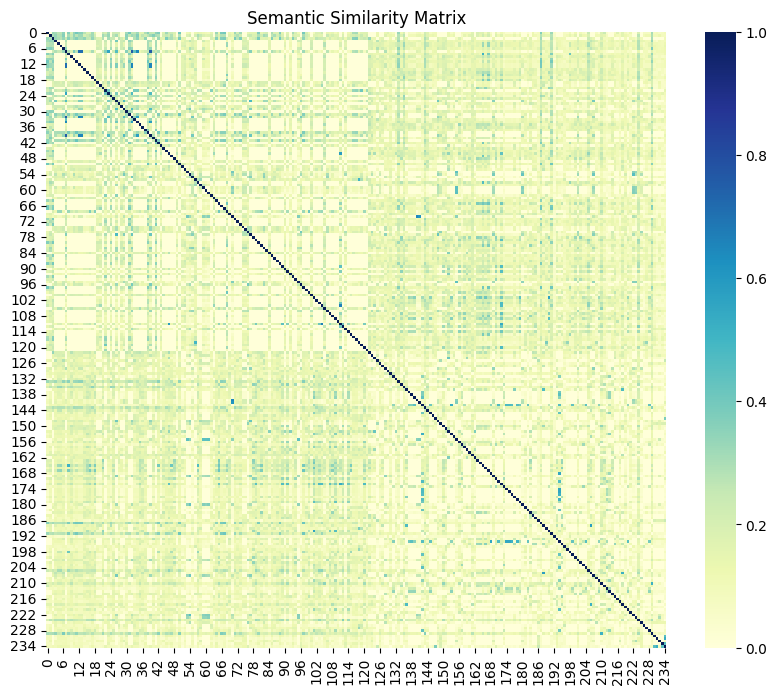

,0,1,2,3,4,5,6,7,8,9,...,225,226,227,228,229,230,231,232,233,234
0,1.00,0.00,0.33,0.31,0.27,0.27,0.35,0.00,0.36,0.20,...,0.00,0.07,0.08,0.07,0.31,0.08,0.09,0.07,0.08,0.10
1,0.00,1.00,0.29,0.33,0.28,0.29,0.36,0.00,0.31,0.24,...,0.00,0.10,0.12,0.12,0.29,0.10,0.10,0.13,0.08,0.09
2,0.33,0.29,1.00,0.32,0.30,0.27,0.33,0.24,0.36,0.28,...,0.10,0.00,0.00,0.00,0.30,0.00,0.00,0.00,0.00,0.10
3,0.31,0.33,0.32,1.00,0.00,0.00,0.00,0.29,0.00,0.00,...,0.15,0.14,0.11,0.11,0.34,0.07,0.04,0.10,0.09,0.10
4,0.27,0.28,0.30,0.00,1.00,0.00,0.00,0.24,0.00,0.00,...,0.11,0.07,0.11,0.15,0.26,0.11,0.11,0.10,0.09,0.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,0.08,0.10,0.00,0.07,0.11,0.13,0.12,0.09,0.11,0.06,...,0.14,0.00,0.00,0.00,0.08,1.00,0.00,0.00,0.00,0.46
231,0.09,0.10,0.00,0.04,0.11,0.11,0.12,0.12,0.08,0.06,...,0.15,0.00,0.00,0.00,0.04,0.00,1.00,0.00,0.00,0.53
232,0.07,0.13,0.00,0.10,0.10,0.10,0.10,0.11,0.09,0.08,...,0.13,0.00,0.00,0.00,0.09,0.00,0.00,1.00,0.00,0.07
233,0.08,0.08,0.00,0.09,0.09,0.10,0.11,0.12,0.09,0.06,...,0.13,0.00,0.00,0.00,0.06,0.00,0.00,0.00,1.00,0.44


Clustered term table:


,canonical_source,name,standardized_name,cluster_id,cluster_label,semantic_similarity_max
110,GO:BP,reactive oxygen species metabolic process,reactive oxygen species metabolic process,0,reactive oxygen species metabolic process,0.267916
216,REAC,KEAP1-NFE2L2 pathway,keap1 nfe2l2 pathway,1,keap1 nfe2l2 pathway,0.267916
181,KEGG,Longevity regulating pathway,longevity regulating pathway,2,longevity regulating pathway,0.262222
192,GO:MF,L-leucine binding,l leucine binding,3,l leucine binding,0.262222
62,GO:BP,intrinsic apoptotic signaling pathway in respo...,intrinsic apoptotic signaling pathway in respo...,4,intrinsic apoptotic signaling pathway in respo...,0.362500
...,...,...,...,...,...,...
190,REAC,G2/M DNA damage checkpoint,g2 m dna damage checkpoint,222,dna damage checkpoint signaling,0.564035
109,GO:BP,DNA integrity checkpoint signaling,dna integrity checkpoint signaling,223,dna integrity checkpoint signaling,0.456667
179,REAC,DNA Double-Strand Break Repair,dna double strand break repair,224,dna double strand break repair,0.441179
182,REAC,Resolution of D-loop Structures through Synthe...,resolution of d loop structures through synthe...,225,resolution of d loop structures through synthe...,0.426667


Database-level cluster consistency matrix:


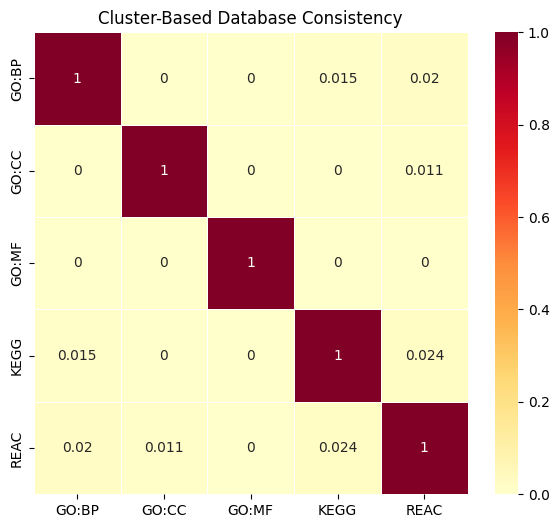

,GO:BP,GO:CC,GO:MF,KEGG,REAC
GO:BP,1.00,0.00,0.0,0.02,0.02
GO:CC,0.00,1.00,0.0,0.00,0.01
GO:MF,0.00,0.00,1.0,0.00,0.00
KEGG,0.02,0.00,0.0,1.00,0.02
REAC,0.02,0.01,0.0,0.02,1.00


Validation summary:
{'is_valid': True, 'issues': [], 'shape': (5, 5)}
Cluster summary:
{'term_count': 235, 'cluster_count': 227, 'singleton_cluster_count': 220, 'multi_source_cluster_count': 7, 'mean_cluster_size': 1.0352422907488987}


In [32]:
small_similarity = build_semantic_similarity_matrix(small_results)
small_clustered = cluster_terms(small_results, similarity_threshold=0.55)
small_cluster_matrix = build_cluster_consistency_matrix(small_clustered)

print("Term-term similarity matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(small_similarity, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Semantic Similarity Matrix")
plt.show()
display(small_similarity.round(2))

print("Clustered term table:")
display(
    small_clustered[[
        "canonical_source",
        "name",
        "standardized_name",
        "cluster_id",
        "cluster_label",
        "semantic_similarity_max",
    ]].sort_values(["cluster_id", "canonical_source"])
)

print("Database-level cluster consistency matrix:")
plt.figure(figsize=(7, 6))
sns.heatmap(
    small_cluster_matrix,
    annot=True,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Cluster-Based Database Consistency")
plt.show()
display(small_cluster_matrix.round(2))

validation = validate_score_matrix(
    small_cluster_matrix,
    expected_min=0.0,
    expected_max=1.0,
    diagonal_mode="one",
)
summary = summarize_cluster_quality(small_clustered)

print("Validation summary:")
print(validation)
print("Cluster summary:")
print(summary)
